# Low-dimensional Q70 Type I error and size-adjusted power experiments (v7)

This all-English notebook follows the experiment order in **Q70_quantile_v2**:

1. Setup and Q70 DGP registration.
2. Global settings and the two fixed learning configurations.
3. Oracle H0 check.
4. Learned-generator H0 experiments for both methods.
5. Raw Type I error tables and method-specific empirical cutoffs.
6. H1 size-adjusted power for both methods.
7. Comparison tables, power curves, and saved results.

**Pure MMD** uses the exact baseline configuration from the supplied v2 notebook. **MMD + Q70 alignment** uses the v6 default aligned configuration, including `lambda_align=0.01`, which the user reports now gives acceptable Type I error fluctuation. No new rejection-rate values are assumed or inserted here.

Both methods run by default, with 100 H0 repetitions and 100 H1 repetitions per dependence strength at n=400. Their H0 cells remain separate so either method can be rerun independently. The alignment configuration is fixed; no lambda search or additional retuning is performed.

The inference core and unified Q70 DGP are embedded as in v6, so this notebook does not depend on a separately modified ci_test.py. Per-seed checkpoints, explicit multi-GPU assignment, and configuration-checked resumption are retained. H0 and H1 use nonoverlapping seed ranges.

## 0. Setup

In [1]:
# Uncomment only if these dependencies are missing.
# %pip install numpy pandas matplotlib torch joblib
# Keep a working CUDA PyTorch installation instead of upgrading it unnecessarily.
import json, math, hashlib, os, gc, types
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from joblib import Parallel, delayed
from IPython.display import display

### 0.1 Register the Q70 DGP and load the inference core

The embedded code is retained from v6. It includes the original training loss, fold-specific standardization, fresh generators for each cross-fitting fold, and Gaussian wild bootstrap. Training telemetry records epochs and learning rates without changing the optimization path.

For Z ~ N(0, I_10), the piecewise inverse CDF yields zero conditional means and medians and nonlinear conditional Q70 levels h_X(Z) and h_Y(Z). Under H0 the latent uniforms are independent. Under H1 a checkerboard copula couples their Q70 exceedance indicators while preserving both conditional marginals. The Q70 DGP also has varying conditional tails and variances.

In [4]:
CORE_SOURCE = '"""\nci_test.py\n==========\nDoubly-robust conditional independence (CI) test with generative neural networks,\nfollowing Zhang, Huang, Yang & Shao (2026, JRSSB), refactored from the original\n``skew_*.ipynb`` experiments.\n\nThis version fixes the Type-I-error inflation observed on the skewed / heteroscedastic\ndata-generating process. The diagnosis (see the accompanying report) was that the test\nstatistic and the wild bootstrap are correct -- with the *true* conditional generators\nthe size is exactly nominal -- but the learned generators were badly under-trained:\nthey collapsed the conditional standard deviation to about half of the truth, which\nbreaks the double-robustness the size guarantee relies on.\n\nFixes applied here, relative to the original notebooks\n------------------------------------------------------\n1. Proper generator training: learning rate 5e-4 (was 5e-5), no aggressive gradient\n   clipping (was clip_grad_norm=0.5, which throttled almost every step), more epochs.\n2. Standardization is actually applied (the original passed ``preprocess=\'scale\'`` but\n   never used it). Each variable is z-scored using the *training* fold\'s statistics.\n3. Selectable alignment penalty (``align_mode``): \'median\' (the student\'s original\n   median pinball -- the default here, faithful to her method), \'mean\' (the tutorial\'s\n   E[X|Z] MSE idea), \'quantile\' (an OPTIONAL spread-aware multi-quantile pinball), or\n   \'none\'. The median penalty pins the center; the multi-quantile variant additionally\n   matches the conditional *spread* (a spread-aware extension, kept optional).\n4. Honest cross-fitting: a FRESH generator is trained on each fold\'s training data\n   (the original created the generators once and warm-started them across folds, so\n   later test folds had already been seen during training).\n5. Configurable generator depth / width (the seven original notebooks differed only\n   in these two numbers).\n6. Vectorized conditional-MMD losses (faster and easier to read).\n7. Oracle mode is kept as a built-in size sanity-check.\n8. Pluggable data-generating models via a small DGP registry, so a student can switch\n   between DGPs (e.g. this project\'s skewed one and the paper\'s Section 4.1 Gaussian\n   model) or register their own with ``register_dgp`` -- see :class:`DGP`.\n\nThe public entry points are :func:`run_ci_test` (one dataset -> one p-value) and\n:func:`run_experiment` (Monte-Carlo rejection rate over many datasets); both take a\n``dgp`` argument (a name in ``DGPS`` or a :class:`DGP` object).\n"""\n\nfrom __future__ import annotations\nimport numpy as np\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nimport torch.optim as optim\n\n\n# ----------------------------------------------------------------------------------\n# reproducibility / device\n# ----------------------------------------------------------------------------------\ndef set_seed(seed: int) -> None:\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\n\ndef get_device(prefer_gpu: bool = True) -> torch.device:\n    if prefer_gpu and torch.cuda.is_available():\n        return torch.device("cuda")\n    # Apple-Silicon GPU (Metal). Verified numerically identical to CPU here and ~6x\n    # faster for a single learned run; torch>=2.x runs cdist/quantile/median natively.\n    mps = getattr(torch.backends, "mps", None)\n    if prefer_gpu and mps is not None and mps.is_available():\n        return torch.device("mps")\n    return torch.device("cpu")\n\n\n# ----------------------------------------------------------------------------------\n# data-generating process (skewed, heteroscedastic, nonlinear-mean)\n# ----------------------------------------------------------------------------------\ndef _standardized_lognormal(num, dim, sigma=1.0, device=None):\n    """Right-skewed noise with mean 0 and variance 1 (shifted, scaled lognormal)."""\n    n = torch.randn(num, dim, device=device)\n    denom = np.sqrt((np.exp(sigma ** 2) - 1.0) * np.exp(sigma ** 2))\n    return (torch.exp(sigma * n) - 1.0) / denom\n\n\ndef _mean_std_functions(z1, linear_mean=False):\n    """Conditional mean / std of X|Z and Y|Z as functions of the first coordinate of Z.\n    ``linear_mean=True`` uses the simplified linear means m_X=0.8z, m_Y=-0.6z from\n    Simulation 8 (nonlinear otherwise)."""\n    sig = torch.sigmoid\n    if linear_mean:\n        m_x = 0.8 * z1\n        m_y = -0.6 * z1\n    else:\n        m_x = 0.8 * z1 + 0.5 * torch.sin(1.5 * z1)\n        m_y = -0.6 * z1 + 0.4 * (z1 ** 2)\n    s_x = 0.5 + 0.25 * torch.abs(z1) + 0.15 * sig(z1)\n    s_y = 0.5 + 0.20 * torch.abs(z1) + 0.15 * sig(-z1)\n    return m_x, m_y, s_x, s_y\n\n\ndef sample_data(n, hypothesis="H0", dx=1, dy=1, dz=1, nstd=1.0, alpha_x=0.20,\n                dist_z="gaussian", lognormal_sigma=1.0, linear_mean=False, device=None):\n    """Draw ``n`` i.i.d. triples (X, Y, Z) from the skewed DGP.\n\n    Under ``H0`` the noise terms of X and Y are independent given Z, so X _|_ Y | Z.\n    Under ``H1`` a Bernoulli(alpha_x) fraction of samples share Y\'s noise in X, which\n    injects conditional dependence whose strength grows with ``alpha_x``.\n    """\n    if dist_z == "gaussian":\n        Z = torch.randn(n, dz, device=device)\n    elif dist_z == "laplace":\n        Z = torch.distributions.Laplace(0.0, 1.0).sample((n, dz)).to(device)\n    else:\n        raise ValueError("dist_z must be \'gaussian\' or \'laplace\'.")\n\n    eps_x = _standardized_lognormal(n, dx, lognormal_sigma, device)\n    eps_y = _standardized_lognormal(n, dy, lognormal_sigma, device)\n\n    z1 = Z[:, [0]]\n    m_x, m_y, s_x, s_y = _mean_std_functions(z1, linear_mean)\n    if dx > 1:\n        m_x, s_x = m_x.repeat(1, dx), s_x.repeat(1, dx)\n    if dy > 1:\n        m_y, s_y = m_y.repeat(1, dy), s_y.repeat(1, dy)\n\n    Y = m_y + nstd * s_y * eps_y\n    if hypothesis == "H0":\n        X = m_x + nstd * s_x * eps_x\n    elif hypothesis == "H1":\n        if 1 < dy < dx:\n            raise ValueError(\n                "H1 noise-sharing is undefined for dx > dy > 1 (cannot map dy>1 shared "\n                "noise columns onto a wider X); use dx <= dy, or dy == 1.")\n        delta = torch.bernoulli(torch.full((n, 1), float(alpha_x), device=device))\n        delta_x = delta.repeat(1, dx) if dx > 1 else delta\n        shared = eps_y if dx == dy else (eps_y.repeat(1, dx) if dy == 1 else eps_y[:, :dx])\n        X = m_x + nstd * s_x * ((1.0 - delta_x) * eps_x + delta_x * shared)\n    else:\n        raise ValueError("hypothesis must be \'H0\' or \'H1\'.")\n    return X, Y, Z\n\n\ndef oracle_conditional_sample(Z, m, dx=1, dy=1, nstd=1.0, lognormal_sigma=1.0,\n                              linear_mean=False, device=None, **_):\n    """Sample ``m`` draws of (X, Y) from the TRUE conditionals P(X|z), P(Y|z) for each\n    row ``z`` of ``Z``. Used for the oracle size sanity-check. Returns tensors of shape\n    (len(Z), m, dx) and (len(Z), m, dy). (The marginal conditionals are the same under\n    H0 and H1 for this DGP, so no hypothesis argument is needed; extra kwargs like\n    ``dist_z`` / ``alpha_x`` are accepted and ignored.)"""\n    n = Z.shape[0]\n    z1 = Z[:, [0]]\n    m_x, m_y, s_x, s_y = _mean_std_functions(z1, linear_mean)       # (n, 1)\n    eps_x = _standardized_lognormal(n * m, dx, lognormal_sigma, device).reshape(n, m, dx)\n    eps_y = _standardized_lognormal(n * m, dy, lognormal_sigma, device).reshape(n, m, dy)\n    X = m_x.unsqueeze(1) + nstd * s_x.unsqueeze(1) * eps_x\n    Y = m_y.unsqueeze(1) + nstd * s_y.unsqueeze(1) * eps_y\n    return X, Y\n\n\n# ----------------------------------------------------------------------------------\n# Second DGP: the Gaussian post-linear model from Zhang et al. Section 4.1\n#   Z = e3,  Y = Z + e1,  X = Z + delta*e1 + (1-delta)*e2,  delta ~ Bernoulli(alpha_x)\n# with e1, e2, e3 ~ N(0,1) independent. Under H0 (alpha_x=0) X = Z + e2 _|_ Y | Z; the\n# conditional dependence strength grows with alpha_x. This is an "easy" DGP (Gaussian,\n# homoscedastic, linear mean) -- a useful contrast to the hard skewed one.\n# ----------------------------------------------------------------------------------\ndef sample_gaussian(n, hypothesis="H0", dz=1, alpha_x=0.20, device=None, **_):\n    Z = torch.randn(n, dz, device=device)\n    z1 = Z[:, [0]]\n    e1 = torch.randn(n, 1, device=device)\n    e2 = torch.randn(n, 1, device=device)\n    Y = z1 + e1\n    if hypothesis == "H0":\n        X = z1 + e2\n    elif hypothesis == "H1":\n        delta = torch.bernoulli(torch.full((n, 1), float(alpha_x), device=device))\n        X = z1 + delta * e1 + (1.0 - delta) * e2\n    else:\n        raise ValueError("hypothesis must be \'H0\' or \'H1\'.")\n    return X, Y, Z\n\n\ndef oracle_gaussian(Z, m, device=None, **_):\n    """True conditionals: X|Z ~ N(z1, 1) and Y|Z ~ N(z1, 1) (same under H0 and H1)."""\n    n = Z.shape[0]\n    z1 = Z[:, [0]].unsqueeze(1)                       # (n, 1, 1)\n    X = z1 + torch.randn(n, m, 1, device=device)\n    Y = z1 + torch.randn(n, m, 1, device=device)\n    return X, Y\n\n\n# ----------------------------------------------------------------------------------\n# Heteroskedastic model (Simulation 5, Section 3.1): X has a Z-dependent variance and\n# ZERO conditional mean, so mean-alignment is useless by design.\n#   Y = Z + ey,  sigma(Z) = 0.3 + 1.2|Z|,  H0: X = sigma(Z) ex\n#   H1: X = sigma(Z)[(1-d) ex + d ey],  d ~ Bernoulli(alpha_x)\n# ----------------------------------------------------------------------------------\ndef sample_heteroskedastic(n, hypothesis="H0", dz=1, alpha_x=0.20, device=None, **_):\n    Z = torch.randn(n, dz, device=device)\n    z1 = Z[:, [0]]\n    ex = torch.randn(n, 1, device=device)\n    ey = torch.randn(n, 1, device=device)\n    sig = 0.3 + 1.2 * z1.abs()\n    Y = z1 + ey\n    if hypothesis == "H0":\n        X = sig * ex\n    elif hypothesis == "H1":\n        d = torch.bernoulli(torch.full((n, 1), float(alpha_x), device=device))\n        X = sig * ((1.0 - d) * ex + d * ey)\n    else:\n        raise ValueError("hypothesis must be \'H0\' or \'H1\'.")\n    return X, Y, Z\n\n\ndef oracle_heteroskedastic(Z, m, device=None, **_):\n    n = Z.shape[0]\n    z1 = Z[:, [0]].unsqueeze(1)\n    sig = 0.3 + 1.2 * z1.abs()\n    X = sig * torch.randn(n, m, 1, device=device)         # X|Z ~ N(0, sigma(Z)^2)\n    Y = z1 + torch.randn(n, m, 1, device=device)          # Y|Z ~ N(z1, 1)\n    return X, Y\n\n\n# ----------------------------------------------------------------------------------\n# Heavy-tailed Student-t model (Simulation 5, Section 4): heteroskedastic with heavy\n# tails, so the conditional median is a more stable target than the mean.\n#   mX=mY=Z,  s(Z) = 0.5 + |Z|,  eX, eY ~ standardized Student-t (df, unit variance)\n#   H0: X = Z + s(Z)eX, Y = Z + s(Z)eY\n#   H1: X = Z + s(Z)eX, Y = Z + s(Z)[d eX + (1-d) eY],  d ~ Bernoulli(alpha_x)\n# ----------------------------------------------------------------------------------\ndef _standardized_t(shape, df, device):\n    """Student-t scaled to unit variance (requires df > 2)."""\n    t = torch.distributions.StudentT(float(df)).sample(shape).to(device)\n    return t * float(np.sqrt((df - 2.0) / df))\n\n\ndef sample_student_t(n, hypothesis="H0", dz=1, alpha_x=0.20, df=3.0, device=None, **_):\n    Z = torch.randn(n, dz, device=device)\n    z1 = Z[:, [0]]\n    s = 0.5 + z1.abs()\n    eX = _standardized_t((n, 1), df, device)\n    eY = _standardized_t((n, 1), df, device)\n    X = z1 + s * eX\n    if hypothesis == "H0":\n        Y = z1 + s * eY\n    elif hypothesis == "H1":\n        d = torch.bernoulli(torch.full((n, 1), float(alpha_x), device=device))\n        Y = z1 + s * (d * eX + (1.0 - d) * eY)\n    else:\n        raise ValueError("hypothesis must be \'H0\' or \'H1\'.")\n    return X, Y, Z\n\n\ndef oracle_student_t(Z, m, df=3.0, device=None, **_):\n    n = Z.shape[0]\n    z1 = Z[:, [0]].unsqueeze(1)\n    s = 0.5 + z1.abs()\n    X = z1 + s * _standardized_t((n, m, 1), df, device)\n    Y = z1 + s * _standardized_t((n, m, 1), df, device)\n    return X, Y\n\n\n# ----------------------------------------------------------------------------------\n# DGP registry -- lets the notebook / a student swap or add data-generating models.\n# A DGP bundles two functions: how to draw (X, Y, Z), and how to draw from the TRUE\n# conditionals P(X|Z), P(Y|Z) (needed only for the oracle size sanity-check).\n# ----------------------------------------------------------------------------------\nclass DGP:\n    def __init__(self, name, sample, oracle, description=""):\n        self.name = name\n        self._sample = sample          # (n, hypothesis, device, **kw) -> (X, Y, Z)\n        self._oracle = oracle          # (Z, m, device, **kw) -> (X_fake, Y_fake)\n        self.description = description\n\n    def sample(self, n, hypothesis="H0", device=None, **kw):\n        return self._sample(n, hypothesis=hypothesis, device=device, **kw)\n\n    def oracle(self, Z, m, device=None, **kw):\n        return self._oracle(Z, m, device=device, **kw)\n\n\nDGPS = {}\n\n\ndef register_dgp(dgp):\n    """Add a DGP to the registry so it can be selected by name. Returns the DGP."""\n    DGPS[dgp.name] = dgp\n    return dgp\n\n\ndef get_dgp(dgp):\n    """Resolve a DGP given either a name or a DGP object."""\n    if isinstance(dgp, DGP):\n        return dgp\n    if dgp in DGPS:\n        return DGPS[dgp]\n    raise KeyError(f"unknown dgp {dgp!r}; registered: {list(DGPS)}")\n\n\nregister_dgp(DGP(\n    "skew", sample=sample_data, oracle=oracle_conditional_sample,\n    description="This project\'s hard case: skewed lognormal noise, heteroscedastic "\n                "spread, nonlinear means. Knobs: dx, dy, dz, nstd, dist_z, alpha_x."))\nregister_dgp(DGP(\n    "gaussian", sample=sample_gaussian, oracle=oracle_gaussian,\n    description="Zhang et al. Section 4.1 (Sim 4/5): Z=e3, Y=Z+e1, X=Z+d*e1+(1-d)*e2, "\n                "d~Bernoulli(alpha_x). Gaussian / homoscedastic / linear. Knobs: dz, alpha_x."))\nregister_dgp(DGP(\n    "skew_linear",\n    sample=lambda n, hypothesis, device, **kw: sample_data(\n        n, hypothesis, device=device, linear_mean=True, **kw),\n    oracle=lambda Z, m, device, **kw: oracle_conditional_sample(\n        Z, m, device=device, linear_mean=True, **kw),\n    description="Simulation 8 (Sec 1.3): the skewed DGP but with LINEAR means "\n                "m_X=0.8z, m_Y=-0.6z. Knobs: dx, dy, dz, nstd, dist_z, alpha_x."))\nregister_dgp(DGP(\n    "heteroskedastic", sample=sample_heteroskedastic, oracle=oracle_heteroskedastic,\n    description="Simulation 5 (Sec 3.1): Y=Z+ey, X=sigma(Z)*ex, sigma(Z)=0.3+1.2|Z|. "\n                "Gaussian but heteroscedastic with ZERO conditional mean. Knobs: dz, alpha_x."))\nregister_dgp(DGP(\n    "student_t", sample=sample_student_t, oracle=oracle_student_t,\n    description="Simulation 5 (Sec 4): heavy-tailed, mX=mY=Z, s(Z)=0.5+|Z|, standardized "\n                "Student-t noise. Knobs: dz, alpha_x, df (default 3)."))\n\n\n# ----------------------------------------------------------------------------------\n# per-variable standardization (fit on the training fold, applied everywhere)\n# ----------------------------------------------------------------------------------\nclass Scaler:\n    """z-score each column; ``fit`` on training data only to avoid test leakage."""\n    def __init__(self, x):\n        self.mean = x.mean(0, keepdim=True)\n        self.std = x.std(0, keepdim=True).clamp_min(1e-6)\n\n    def transform(self, x):\n        return (x - self.mean) / self.std\n\n\n# ----------------------------------------------------------------------------------\n# conditional generator  G(z, noise) -> target\n# ----------------------------------------------------------------------------------\nclass ConditionalGenerator(nn.Module):\n    """MLP with ``depth`` hidden layers of width ``width``; maps concat(Z, noise) to the\n    target variable. ``depth`` reproduces the 1-/2-/3-layer notebooks."""\n    def __init__(self, z_dim, out_dim, noise_dim, width=1024, depth=3,\n                 relu_slope=0.1, dropout=0.0):\n        super().__init__()\n        dims = [z_dim + noise_dim] + [width] * depth\n        layers = []\n        for a, b in zip(dims[:-1], dims[1:]):\n            layers += [nn.Linear(a, b), nn.LeakyReLU(relu_slope)]\n            if dropout > 0:\n                layers += [nn.Dropout(dropout)]\n        layers += [nn.Linear(width, out_dim)]\n        self.net = nn.Sequential(*layers)\n\n    def forward(self, z, noise):\n        return self.net(torch.cat([z, noise], dim=1))\n\n\ndef sample_noise(n, noise_dim, device, var=1.0, kind="normal"):\n    if kind == "normal":\n        return torch.randn(n, noise_dim, device=device) * np.sqrt(var)\n    if kind == "uniform":\n        return torch.rand(n, noise_dim, device=device)\n    raise ValueError("noise kind must be \'normal\' or \'uniform\'.")\n\n\n# ----------------------------------------------------------------------------------\n# kernels and conditional-MMD training loss (vectorized)\n# ----------------------------------------------------------------------------------\ndef _median_bandwidth(a, p=1):\n    d = torch.cdist(a, a, p=p)\n    d = d[d > 0]\n    return d.median().clamp_min(1e-8).item() if d.numel() else 1.0\n\n\ndef _pairwise(a, b, p):\n    # ||a_i - b_j||_p over the last dim; a:(...,d) b:(...,d)\n    if p == 1:\n        return torch.sum(torch.abs(a - b), dim=-1)\n    return torch.sum((a - b) ** 2, dim=-1)\n\n\ndef conditional_mmd_loss(Y, Y_fake, Z, sigma_z, sigma_y, w_laplacian=1.0, w_gaussian=1.0):\n    """Sample conditional-MMD training loss between P(Y|Z) and the generated P(Yhat|Z).\n\n    ``Y``: (n, d) real targets. ``Y_fake``: (n, M, d) generated targets (M draws per z).\n    ``w_laplacian`` / ``w_gaussian`` weight the two kernels (original ``lambda_1`` /\n    ``lambda_2``); set one to 0 to use a single kernel.\n    """\n    if Y.dim() == 1:\n        Y = Y.reshape(-1, 1)\n    if Y_fake.dim() == 2:\n        Y_fake = Y_fake.unsqueeze(1)\n    n = Z.shape[0]\n    eye = torch.eye(n, device=Y.device)\n\n    def _loss(p, sy):\n        Kz = torch.exp(-torch.cdist(Z, Z, p=1) / sigma_z) if p == 1 \\\n            else torch.exp(-(torch.cdist(Z, Z, p=2) ** 2) / sigma_z)\n        Kyy = torch.exp(-_pairwise(Y[:, None, :], Y[None, :, :], p) / sy)\n        d_yf = _pairwise(Y[:, None, None, :], Y_fake[None, :, :, :], p)     # (n,n,M)\n        Kyf = torch.exp(-d_yf / sy).mean(2)\n        Kfy = Kyf.T\n        d_ff = _pairwise(Y_fake[:, None, :, None, :], Y_fake[None, :, None, :, :], p)\n        Kff = torch.exp(-d_ff / sy).mean(dim=(2, 3))                        # (n,n)\n        FF = (Kyy - Kyf - Kfy + Kff) * Kz * (1 - eye)\n        return FF.sum() / (n * (n - 1))\n\n    out = 0.0\n    if w_laplacian:\n        out = out + w_laplacian * _loss(1, sigma_y)\n    if w_gaussian:\n        out = out + w_gaussian * _loss(2, sigma_y)\n    return out\n\n\ndef alignment_penalty(Y, Y_group, mode="quantile", taus=(0.1, 0.5, 0.9)):\n    """Optional penalty that pulls the generated conditional summary toward the data.\n\n    ``Y``: (n, d) observed.  ``Y_group``: (n, S, d) generated draws per observation.\n    ``mode``:\n        \'none\'     -- no penalty (pure conditional-MMD, as in the original paper).\n        \'mean\'     -- MSE between the generated conditional mean E[Yhat|Z] and Y\n                      (the mean-alignment idea from the tutorial).\n        \'median\'   -- pinball at tau=0.5 (the original notebook\'s ``lambda_median`` term);\n                      pins the center only, so it does NOT fix the spread.\n        \'quantile\' -- multi-quantile pinball over ``taus`` (default 0.1/0.5/0.9);\n                      matches center AND spread -- an optional spread-aware extension.\n    """\n    if Y.dim() == 1:\n        Y = Y.reshape(-1, 1)\n    if mode == "none":\n        return Y.new_zeros(())\n    if mode == "mean":\n        return F.mse_loss(Y_group.mean(dim=1), Y)\n    qs = (0.5,) if mode == "median" else tuple(taus)\n    q = torch.tensor(qs, device=Y.device, dtype=Y.dtype)\n    pred = torch.quantile(Y_group, q, dim=1)           # (T, n, d)\n    diff = Y.unsqueeze(0) - pred\n    qv = q.view(-1, 1, 1)\n    return torch.maximum(qv * diff, (qv - 1.0) * diff).mean()\n\n\n# ----------------------------------------------------------------------------------\n# train ONE conditional generator  target ~ P(target | Z)\n# ----------------------------------------------------------------------------------\ndef train_conditional_generator(target, Z, cfg, device, seed=None):\n    """Train a generator for P(target | Z) by minimizing conditional-MMD plus the\n    multi-quantile alignment penalty. Returns the trained generator (in eval mode).\n\n    ``epochs`` is a *cap*: if ``early_stop`` is on, training halts once a smoothed\n    (EMA) training loss stops improving for ``patience`` epochs. This makes the run\n    self-tune its length -- important because deeper generators need more epochs to\n    converge, and an under-converged generator is exactly what inflates the size.\n    """\n    if seed is not None:\n        torch.manual_seed(seed)\n    n, out_dim = target.shape\n    G = ConditionalGenerator(Z.shape[1], out_dim, cfg["noise_dim"],\n                             width=cfg["width"], depth=cfg["depth"],\n                             dropout=cfg["dropout"]).to(device)\n    opt = optim.Adam(G.parameters(), lr=cfg["lr"], betas=(0.5, 0.999),\n                     weight_decay=cfg["weight_decay"])\n    # Adaptive LR: cut the rate when the smoothed loss stalls, giving Adam a finer\n    # step to settle into the minimum instead of just stopping. Keyed to the same\n    # EMA the early stop uses, so the two cooperate (LR drops a few times, and the\n    # drop usually unsticks the loss -> `wait` resets -> we stop only when even the\n    # reduced LR cannot make progress). Only meaningful when early_stop tracks the EMA.\n    sched = None\n    if cfg.get("lr_scheduler", True) and cfg.get("early_stop", True):\n        sched = optim.lr_scheduler.ReduceLROnPlateau(\n            opt, mode="min", factor=cfg.get("lr_factor", 0.5),\n            patience=cfg.get("lr_patience", 15),\n            min_lr=cfg["lr"] * cfg.get("min_lr_frac", 0.05))\n\n    sigma_z = _median_bandwidth(Z, p=1)\n    sigma_t = _median_bandwidth(target, p=1)\n    idx = torch.arange(n, device=device)\n    bs = min(cfg["batch_size"], n)\n    ema, best, wait = None, float("inf"), 0\n    early_stop = cfg.get("early_stop", True)\n\n    training_trace = []\n    for epoch in range(cfg["epochs"]):\n        perm = idx[torch.randperm(n, device=device)]\n        epoch_loss, nb = 0.0, 0\n        for s in range(0, n, bs):\n            b = perm[s:s + bs]\n            if b.numel() < 3:\n                continue\n            Zb, Tb = Z[b], target[b]\n            m = Zb.shape[0]\n\n            # generated draws for the conditional-MMD term\n            Zr = Zb.repeat_interleave(cfg["M_train"], 0)\n            fake = G(Zr, sample_noise(Zr.shape[0], cfg["noise_dim"], device,\n                                      cfg["noise_var"], cfg["noise_kind"])\n                     ).reshape(m, cfg["M_train"], out_dim)\n            loss = conditional_mmd_loss(Tb, fake, Zb, sigma_z, sigma_t,\n                                        cfg["mmd_w_laplacian"], cfg["mmd_w_gaussian"])\n\n            # optional alignment penalty (mean / median / quantile / none)\n            if cfg["align_mode"] != "none" and cfg["lambda_align"] > 0:\n                Zq = Zb.repeat_interleave(cfg["align_samples"], 0)\n                grp = G(Zq, sample_noise(Zq.shape[0], cfg["noise_dim"], device,\n                                         cfg["noise_var"], cfg["noise_kind"])\n                        ).reshape(m, cfg["align_samples"], out_dim)\n                loss = loss + cfg["lambda_align"] * alignment_penalty(\n                    Tb, grp, cfg["align_mode"], cfg["taus"])\n\n            opt.zero_grad()\n            loss.backward()\n            if cfg["grad_clip"] is not None:\n                nn.utils.clip_grad_norm_(G.parameters(), cfg["grad_clip"])\n            opt.step()\n            nb += 1\n            # float(...) forces a device->host sync; only needed for early stopping,\n            # so skip it entirely when early stopping is off (e.g. the runner scripts).\n            if early_stop:\n                epoch_loss += float(loss.detach())\n\n        # early stopping on a smoothed training loss (after a warm-up)\n        if early_stop and nb > 0:\n            epoch_loss /= nb\n            ema = epoch_loss if ema is None else 0.85 * ema + 0.15 * epoch_loss\n            if sched is not None:\n                sched.step(ema)\n            if epoch % 10 == 0:\n                training_trace.append(dict(epoch=epoch + 1, train_ema=float(ema), lr=float(opt.param_groups[0]["lr"])))\n            if epoch >= cfg.get("min_epochs", 60):\n                if ema < best - cfg.get("min_delta", 1e-4):\n                    best, wait = ema, 0\n                else:\n                    wait += 1\n                    if wait >= cfg.get("patience", 40):\n                        break\n    G.training_summary_v6 = dict(epochs_run=epoch + 1, final_lr=float(opt.param_groups[0]["lr"]),\n        train_ema=None if ema is None else float(ema), trace=training_trace)\n    return G.eval()\n\n\n@torch.no_grad()\ndef generate_conditional(G, Z, m, cfg, device):\n    """Draw ``m`` samples of the target for each row of ``Z``. Returns (len(Z), m, d)."""\n    Zr = Z.repeat_interleave(m, 0)\n    out = G(Zr, sample_noise(Zr.shape[0], cfg["noise_dim"], device,\n                             cfg["noise_var"], cfg["noise_kind"]))\n    return out.reshape(Z.shape[0], m, -1)\n\n\n# ----------------------------------------------------------------------------------\n# test statistic (degenerate U-statistic) + wild bootstrap\n# ----------------------------------------------------------------------------------\ndef _residual_gram(real, fake, sigma):\n    """Û[i,j] = K(r_i,r_j) - mean_m K(r_i, f_j^m) - mean_m K(r_j, f_i^m)\n                + mean_{m,m\'} K(f_i^m, f_j^m\'),  Laplacian kernel.\n    ``real``:(n,d)  ``fake``:(n,M,d). Loops over M for the fake-fake term to stay\n    memory-safe for the larger test-fold sizes."""\n    n, M, _ = fake.shape\n    Krr = torch.exp(-torch.cdist(real, real, p=1) / sigma)\n    d_rf = _pairwise(real[:, None, None, :], fake[None, :, :, :], 1)  # (n,n,M)\n    Krf = torch.exp(-d_rf / sigma).mean(2)\n    Kfr = Krf.T\n    Kff = torch.zeros(n, n, device=real.device)\n    for mm in range(M):\n        d = _pairwise(fake[:, mm, :][:, None, None, :], fake[None, :, :, :], 1)  # (n,n,M)\n        Kff += torch.exp(-d / sigma).mean(2)\n    Kff /= M\n    return Krr - Krf - Kfr + Kff\n\n\ndef ci_statistic_and_bootstrap(X, Y, Z, X_fake, Y_fake, sigma_x, sigma_y, sigma_z,\n                               n_boot=1000, rv="gaussian", device=None):\n    """Return (statistic, bootstrap_null_samples) for one fold. The statistic is the\n    degenerate U-statistic U_X * U_Y * K_Z averaged over off-diagonal pairs; the wild\n    bootstrap injects independent multipliers e_i e_j on each pair."""\n    n = X.shape[0]\n    U = _residual_gram(X, X_fake, sigma_x)\n    V = _residual_gram(Y, Y_fake, sigma_y)\n    Kz = torch.exp(-torch.cdist(Z, Z, p=1) / sigma_z)\n    FF = U * V * Kz * (1 - torch.eye(n, device=device))\n    norm = 1.0 / (n * (n - 1))\n    stat = norm * FF.sum()\n\n    if rv == "rademacher":\n        e = torch.sign(torch.randn(n, n_boot, device=device))\n    else:\n        e = torch.randn(n, n_boot, device=device)\n    # boot[b] = norm * sum_{i,j} FF[i,j] e_i^b e_j^b  =  norm * e_b^T FF e_b\n    boot = norm * torch.einsum("ib,ij,jb->b", e, FF, e)\n    return stat.item(), boot.cpu().numpy()\n\n\n# ----------------------------------------------------------------------------------\n# full CI test on one dataset (cross-fitting, fresh generator per fold)\n# ----------------------------------------------------------------------------------\n# ----------------------------------------------------------------------------------\n# All tunables in one place. The trailing comment gives the matching name in the\n# original notebooks\' ``param`` dict, so nothing here should feel unfamiliar.\n# ----------------------------------------------------------------------------------\nDEFAULT_CONFIG = dict(\n    # --- generator architecture ---\n    depth=2,              # number of hidden layers: 1/2/3 == old skew_1 / skew_2 / skew_3\n    width=1024,           # hidden width                                  (hidden_layer_size)\n    noise_dim=5,          # latent noise dimension                        (noise_dimension)\n    noise_var=1.0,        # latent noise variance                         (noise_dimension_var)\n    noise_kind="normal",  # \'normal\' or \'uniform\'                         (noise_dimension_type)\n    dropout=0.0,          # dropout prob in the generator                 (drop_out_p)\n\n    # --- generator training  (this block is the main Type-I-error fix) ---\n    lr=5e-4,              # Adam learning rate  (was 5e-5 -> too small)   (G_lr)\n    epochs=600,           # CAP on epochs; early stopping usually ends earlier (epochs_num)\n    batch_size=128,       #                                               (batch_size)\n    grad_clip=None,       # max grad norm; None = off  (was 0.5 -> throttled learning)\n    weight_decay=1e-5,    # Adam weight decay                             (wgt_decay)\n    M_train=20,           # generated draws per z for the training MMD    (M_train)\n    mmd_w_laplacian=1.0,  # weight on the Laplacian-kernel MMD term        (lambda_1)\n    mmd_w_gaussian=1.0,   # weight on the Gaussian-kernel MMD term         (lambda_2)\n\n    # --- early stopping (new; makes training length self-tune to the architecture) ---\n    early_stop=True,      # halt when the smoothed training loss plateaus\n    min_epochs=60,        # always train at least this many epochs first\n    patience=40,          # stop after this many epochs with no improvement\n    min_delta=1e-4,       # smallest loss drop that counts as improvement\n\n    # --- adaptive learning-rate schedule (ReduceLROnPlateau on the same EMA loss) ---\n    lr_scheduler=True,    # halve the LR when the smoothed loss plateaus, before stopping\n    lr_factor=0.5,        # multiply LR by this on each plateau\n    lr_patience=15,       # epochs of no improvement before a LR cut (< `patience`)\n    min_lr_frac=0.05,     # LR floor as a fraction of the initial lr\n\n    # --- alignment penalty  (extends the original median penalty) ---\n    align_mode="median",     # \'none\' | \'mean\' | \'median\' | \'quantile\'\n                             #   \'median\'   == the student\'s original penalty (DEFAULT; faithful)\n                             #   \'mean\'     == the tutorial\'s E[X|Z] MSE idea\n                             #   \'quantile\' == spread-aware multi-quantile (optional extension)\n    lambda_align=0.5,        # penalty weight                             (lambda_median)\n    taus=(0.1, 0.5, 0.9),    # quantiles used when align_mode=\'quantile\'\n    align_samples=64,        # generated draws per z for the penalty      (median_samples)\n\n    # --- test statistic / wild bootstrap ---\n    n_folds=2,            # cross-fitting folds J                         (k_value)\n    M_test=100,           # generated draws per z for the statistic       (m_value)\n    n_boot=1000,          # wild-bootstrap replicates B                   (j_value)\n    boot_rv="gaussian",   # bootstrap multiplier: \'gaussian\' or \'rademacher\' (boor_rv_type)\n\n    # --- data handling ---\n    standardize=True,     # z-score X,Y,Z per fold  (original preprocess=\'scale\' was ignored)\n)\n# NOTE. A few original knobs were intentionally dropped as negligible or superseded:\n#   lambda_3 / lambda_4 (tiny 1e-5 L1 penalties) -> folded into weight_decay;\n#   using_Gen \'1\'/\'2\' and is_sparse/sparse_ratio -> replaced by the single \'depth\' knob;\n#   normal_ini -> default PyTorch initialization.\n# Data-generating knobs (sample_size, dx, dy, z_dim, eps_std, dist_z, alpha_x) are passed\n# to run_experiment via n / data_kwargs; see that function.\n\n\ndef run_ci_test(X, Y, Z, config=None, oracle=False, device=None, seed=0,\n                dgp="skew", dgp_kwargs=None):\n    """Cross-fitted CI test on a single dataset. Returns the bootstrap p-value.\n\n    A fresh generator is trained on each fold\'s training data (no warm-start leakage);\n    if ``oracle=True`` the true conditionals of ``dgp`` are used instead of learned\n    generators, which should sit at the nominal level and serves as a size sanity-check.\n    ``dgp`` is only consulted in oracle mode (to draw from the matching true conditionals).\n    """\n    cfg = {**DEFAULT_CONFIG, **(config or {})}\n    dgp = get_dgp(dgp)\n    dgp_kwargs = dgp_kwargs or {}\n    device = device or get_device()\n    X, Y, Z = X.to(device), Y.to(device), Z.to(device)\n    n = X.shape[0]\n    folds = np.array_split(np.random.permutation(n), cfg["n_folds"])\n\n    stats, boots = [], []\n    for j, test_idx in enumerate(folds):\n        test_idx = torch.as_tensor(test_idx, device=device)\n        train_mask = torch.ones(n, dtype=torch.bool, device=device)\n        train_mask[test_idx] = False\n        Xtr, Ytr, Ztr = X[train_mask], Y[train_mask], Z[train_mask]\n        Xte, Yte, Zte = X[test_idx], Y[test_idx], Z[test_idx]\n\n        # standardize using the TRAINING fold only\n        if cfg["standardize"]:\n            sx, sy, sz = Scaler(Xtr), Scaler(Ytr), Scaler(Ztr)\n            Xtr, Ytr, Ztr = sx.transform(Xtr), sy.transform(Ytr), sz.transform(Ztr)\n            Xte, Yte, Zte = sx.transform(Xte), sy.transform(Yte), sz.transform(Zte)\n\n        if oracle:\n            # true conditionals of this DGP, standardized with the same scaler\n            Z_orig = (Zte * sz.std + sz.mean) if cfg["standardize"] else Zte\n            Xf, Yf = dgp.oracle(Z_orig, cfg["M_test"], device=device, **dgp_kwargs)\n            if cfg["standardize"]:\n                Xf = (Xf - sx.mean.unsqueeze(1)) / sx.std.unsqueeze(1)\n                Yf = (Yf - sy.mean.unsqueeze(1)) / sy.std.unsqueeze(1)\n        else:\n            Gx = train_conditional_generator(Xtr, Ztr, cfg, device, seed=seed * 100 + j)\n            Gy = train_conditional_generator(Ytr, Ztr, cfg, device, seed=seed * 100 + 50 + j)\n            Xf = generate_conditional(Gx, Zte, cfg["M_test"], cfg, device)\n            Yf = generate_conditional(Gy, Zte, cfg["M_test"], cfg, device)\n\n        # median-heuristic bandwidths on the test fold (in the space used for the stat)\n        sig_x = _median_bandwidth(Xte, 1)\n        sig_y = _median_bandwidth(Yte, 1)\n        sig_z = _median_bandwidth(Zte, 1)\n\n        stat, boot = ci_statistic_and_bootstrap(\n            Xte, Yte, Zte, Xf, Yf, sig_x, sig_y, sig_z,\n            n_boot=cfg["n_boot"], rv=cfg["boot_rv"], device=device)\n        stats.append(stat)\n        boots.append(boot)\n\n    T = float(np.mean(stats))\n    T_boot = np.mean(np.stack(boots, 0), axis=0)\n    return float(np.mean(T_boot > T))\n\n\n# ----------------------------------------------------------------------------------\n# Monte-Carlo experiment (rejection rate)\n# ----------------------------------------------------------------------------------\ndef _one_replicate(seed, n, hypothesis, config, oracle, data_kwargs, prefer_gpu, dgp):\n    set_seed(seed)\n    device = get_device(prefer_gpu)\n    X, Y, Z = get_dgp(dgp).sample(n, hypothesis=hypothesis, device=device, **data_kwargs)\n    return run_ci_test(X, Y, Z, config=config, oracle=oracle, device=device, seed=seed,\n                       dgp=dgp, dgp_kwargs=data_kwargs)\n\n\ndef run_experiment(n=400, hypothesis="H0", n_rep=200, config=None, oracle=False,\n                   levels=(0.10, 0.05), data_kwargs=None, dgp="skew", n_jobs=1,\n                   prefer_gpu=True, verbose=True):\n    """Estimate the rejection rate over ``n_rep`` datasets. Under H0 this is the\n    empirical size; under H1 (with ``alpha_x`` in ``data_kwargs``) it is the power.\n\n    Parameters mapped to the original notebooks\' ``param`` dict:\n        n           sample size per dataset                    (sample_size)\n        hypothesis  \'H0\' (size) or \'H1\' (power)                (test: \'type1error\'/\'power\')\n        n_rep       number of Monte-Carlo datasets             (n_test)\n        levels      significance levels to report              (alpha, alpha1)\n        oracle      use the true conditionals                  (using_orcale)\n        config      the model/test settings (see DEFAULT_CONFIG)\n        dgp         which data-generating model: a name in DGPS (\'skew\', \'gaussian\')\n                    or a DGP object you registered yourself\n        data_kwargs extra knobs forwarded to the chosen DGP, e.g. for \'skew\':\n                        dx, dy      dims of X, Y                (dx, dy)\n                        dz          dim of Z                    (z_dim)\n                        nstd        noise scale                 (eps_std)\n                        dist_z      \'gaussian\' or \'laplace\'     (dist_z)\n                        alpha_x     H1 dependence strength      (alpha_x)\n                    and for \'gaussian\': dz, alpha_x.\n\n    Acceleration is automatic: if an Apple ``mps`` or CUDA GPU is available (and\n    ``prefer_gpu``), every replicate runs on it and ``n_jobs`` is forced to 1 -- one\n    GPU process already gives the full speedup and extra processes only contend for the\n    single GPU. Only on a CPU-only machine does ``n_jobs>1`` (or -1 for all cores) turn\n    on joblib CPU parallelism. For large multi-config sweeps that want to use the GPU AND\n    the spare CPU cores at once, use the bundled ``runner_cfg.py`` hybrid runner instead.\n    Returns a dict with the rejection rate at each level and the raw p-values.\n    """\n    data_kwargs = data_kwargs or {}\n    _dev = get_device(prefer_gpu)\n    if _dev.type in ("mps", "cuda") and n_jobs != 1:\n        if verbose:\n            print(f"[info] {_dev.type.upper()} GPU detected -> running on GPU with n_jobs=1 "\n                  f"(ignoring n_jobs={n_jobs}; the GPU already accelerates each replicate).")\n        n_jobs = 1\n    if n_jobs == 1:\n        pvals = [_one_replicate(s, n, hypothesis, config, oracle, data_kwargs, prefer_gpu, dgp)\n                 for s in range(n_rep)]\n    else:\n        from joblib import Parallel, delayed\n        pvals = Parallel(n_jobs=n_jobs)(\n            delayed(_one_replicate)(s, n, hypothesis, config, oracle, data_kwargs, False, dgp)\n            for s in range(n_rep))\n    pvals = np.asarray(pvals)\n    rej = {lvl: float(np.mean(pvals < lvl)) for lvl in levels}\n    if verbose:\n        gtag = get_dgp(dgp).name\n        mtag = "ORACLE" if oracle else f"depth={ (config or {}).get(\'depth\', DEFAULT_CONFIG[\'depth\']) }"\n        print(f"[{hypothesis} dgp={gtag} {mtag} n={n} reps={n_rep}] "\n              + "  ".join(f"rej@{lvl:.2f}={rej[lvl]:.3f}" for lvl in levels))\n    return dict(rejection=rej, pvalues=pvals)\n'
DGP_SOURCE = 'def _q70_levels(Z):\n    if Z.ndim != 2 or Z.shape[1] < 5:\n        raise ValueError("The Q70 DGP requires dz >= 5.")\n\n    hx = 0.8 + 0.7 * torch.sigmoid(\n        0.8 * Z[:, [0]]\n        - 0.6 * Z[:, [1]]\n        + 0.4 * torch.sin(Z[:, [2]])\n    )\n    hy = 0.8 + 0.7 * torch.sigmoid(\n        -0.7 * Z[:, [0]]\n        + 0.5 * Z[:, [3]]\n        + 0.3 * torch.cos(Z[:, [4]])\n    )\n    return hx, hy\n\n\ndef _q70_inverse_cdf(u, h):\n    c = 16.0 * h - 8.8\n    left_tail = -c + (u / 0.05) * (c - 1.0)\n    center_left = -1.0 + (u - 0.05) / 0.45\n    center_right = h * (u - 0.50) / 0.20\n    upper_tail = h + 0.2 * (u - 0.70) / 0.30\n\n    return torch.where(\n        u < 0.05,\n        left_tail,\n        torch.where(\n            u < 0.50,\n            center_left,\n            torch.where(u < 0.70, center_right, upper_tail),\n        ),\n    )\n\n\ndef _q70_checkerboard_uniforms(n, tau, rho, device):\n    if not 0.0 <= rho <= 1.0:\n        raise ValueError("alpha_x must lie in [0, 1].")\n\n    delta = rho * tau * (1.0 - tau)\n    cell_probabilities = torch.tensor(\n        [\n            tau * tau + delta,\n            tau * (1.0 - tau) - delta,\n            tau * (1.0 - tau) - delta,\n            (1.0 - tau) ** 2 + delta,\n        ],\n        dtype=torch.float32,\n        device=device,\n    )\n\n    cell = torch.multinomial(cell_probabilities, n, replacement=True)\n\n    x_high = (cell >= 2).reshape(-1, 1)\n    y_high = ((cell == 1) | (cell == 3)).reshape(-1, 1)\n\n    ux = torch.where(\n        x_high,\n        tau + (1.0 - tau) * torch.rand(n, 1, device=device),\n        tau * torch.rand(n, 1, device=device),\n    )\n    uy = torch.where(\n        y_high,\n        tau + (1.0 - tau) * torch.rand(n, 1, device=device),\n        tau * torch.rand(n, 1, device=device),\n    )\n\n    return ux, uy\n\n\ndef sample_q70_lowdim(\n    n,\n    hypothesis="H0",\n    device=None,\n    dz=10,\n    alpha_x=0.10,\n    **_,\n):\n    device = device or C.get_device(prefer_gpu=True)\n\n    if int(dz) < 5:\n        raise ValueError("Use dz >= 5 for the Q70 DGP.")\n\n    Z = torch.randn(n, int(dz), device=device)\n    hx, hy = _q70_levels(Z)\n\n    if hypothesis.upper() == "H0":\n        ux = torch.rand(n, 1, device=device)\n        uy = torch.rand(n, 1, device=device)\n    elif hypothesis.upper() == "H1":\n        ux, uy = _q70_checkerboard_uniforms(\n            n=n,\n            tau=0.70,\n            rho=float(alpha_x),\n            device=device,\n        )\n    else:\n        raise ValueError("hypothesis must be \'H0\' or \'H1\'.")\n\n    X = _q70_inverse_cdf(ux, hx)\n    Y = _q70_inverse_cdf(uy, hy)\n    return X, Y, Z\n\n\ndef oracle_q70_lowdim(Z, m, device=None, **_):\n    device = device or Z.device\n    Z = Z.to(device)\n\n    hx, hy = _q70_levels(Z)\n    hx = hx.unsqueeze(1)\n    hy = hy.unsqueeze(1)\n\n    ux = torch.rand(Z.shape[0], m, 1, device=device)\n    uy = torch.rand(Z.shape[0], m, 1, device=device)\n\n    return (\n        _q70_inverse_cdf(ux, hx),\n        _q70_inverse_cdf(uy, hy),\n    )\n\n\nQ70_DGP = C.register_dgp(\n    C.DGP(\n        name="q70_lowdim",\n        sample=sample_q70_lowdim,\n        oracle=oracle_q70_lowdim,\n        description=(\n            "Low-dimensional Q70 DGP: dz=10; conditional means and medians are zero; "\n            "Q0.70 varies nonlinearly with Z; H1 couples the Q70 exceedance cells."\n        ),\n    )\n)\n\n'

CORE_HASH = hashlib.sha256((CORE_SOURCE + DGP_SOURCE).encode()).hexdigest()
def load_core(core_source=CORE_SOURCE, dgp_source=DGP_SOURCE):
    namespace = {"__name__": "q70_embedded_v6"}
    exec(compile(core_source, "<embedded_ci_test_v6>", "exec"), namespace)
    module = types.SimpleNamespace(**namespace)
    env = {"C": module, "torch": module.torch}
    exec(compile(dgp_source, "<q70_dgp_v6>", "exec"), env)
    module.q70_levels = env["_q70_levels"]
    module.q70_inverse_cdf = env["_q70_inverse_cdf"]
    return module

C = load_core()
print("Core hash:", CORE_HASH[:16], "| PyTorch:", torch.__version__)
print("Visible GPUs:", torch.cuda.device_count())

Core hash: ba88706d7675626b | PyTorch: 2.8.0+cu128
Visible GPUs: 4


## 1. Global experiment settings

In [2]:
N = 400
LEVELS = (0.10, 0.05)
DGP_NAME = "q70_lowdim"
BASE_DATA_KWARGS = {"dz": 10}
N_REP_ORACLE = 100
N_REP_H0 = 100
N_REP_H1 = 100
ALPHA_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

# Indices in this process's visible CUDA device list.
GPU_IDS = list(range(torch.cuda.device_count()))
CPU_JOBS = 1
RUN_ORACLE_H0 = True
RUN_BASELINE_H0 = True
RUN_ALIGNED_H0 = True
RUN_BASELINE_POWER = True
RUN_ALIGNED_POWER = True
RELOAD_SAVED_H0 = False

H0_SEEDS = list(range(10000, 10000 + N_REP_H0))
ORACLE_SEEDS = list(range(10000, 10000 + N_REP_ORACLE))
# H1 seed blocks are separate from H0 and from each other.
H1_SEED_START = 30000
H1_SEED_STRIDE = 100000
assert N_REP_H1 <= H1_SEED_STRIDE
assert max(H0_SEEDS + ORACLE_SEEDS) < H1_SEED_START
OUTPUT_DIR = Path("Q70_quantile_v7_results")
OUTPUT_DIR.mkdir(exist_ok=True)
COMPARISON_MODE = "separately_tuned_fixed"
print(dict(n=N, H0_repetitions=N_REP_H0, H1_repetitions_per_strength=N_REP_H1,
           alpha_grid=ALPHA_GRID, GPU_IDS=GPU_IDS))

{'n': 400, 'H0_repetitions': 100, 'H1_repetitions_per_strength': 100, 'alpha_grid': [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4], 'GPU_IDS': [0, 1, 2, 3]}


## 2. Inspect the selected DGP

In [5]:
print(DGP_NAME, "->", C.get_dgp(DGP_NAME).description)
assert BASE_DATA_KWARGS["dz"] >= 5

q70_lowdim -> Low-dimensional Q70 DGP: dz=10; conditional means and medians are zero; Q0.70 varies nonlinearly with Z; H1 couples the Q70 exceedance cells.


## 3. Define the two fixed methods

The dictionaries below explicitly record every effective setting, including values inherited from DEFAULT_CONFIG. The baseline comes from v2; the aligned configuration comes from v6. These are separately tuned methods, so their comparison does not isolate the effect of the alignment penalty alone.

| Setting | Pure MMD: v2 | MMD + Q70: v6 |
|---|---:|---:|
| Hidden layers | 3 | 3 |
| Width | 1024 | 512 |
| Noise dimension | 8 | 8 |
| Learning rate | 0.001 | 0.00075 |
| Epoch cap | 1000 | 800 |
| Batch size | 128 | 128 |
| Weight decay | 0.00001 | 0.0001 |
| M_train | 40 | 40 |
| Minimum epochs | 140 | 100 |
| Early-stop patience | 110 | 80 |
| min_delta | 0.00002 | 0.00001 |
| LR factor | 0.3 | 0.5 |
| LR patience | 20 | 25 |
| Minimum LR fraction | 0.02 | 0.05 |
| lambda_align | 0 | 0.01 |
| align_samples | 64 (inactive) | 256 |

Both use taus=(0.70,), two cross-fitting folds, M_test=100, n_boot=1000, and fold-specific standardization.

In [16]:
CONFIG_MMD_V2 = {'depth': 3, 'width': 1024, 'noise_dim': 8, 'noise_var': 1.0, 'noise_kind': 'normal', 'dropout': 0.0, 'lr': 0.001, 'epochs': 1000, 'batch_size': 128, 'grad_clip': None, 'weight_decay': 1e-05, 'M_train': 40, 'mmd_w_laplacian': 1.0, 'mmd_w_gaussian': 1.0, 'early_stop': True, 'min_epochs': 140, 'patience': 110, 'min_delta': 2e-05, 'lr_scheduler': True, 'lr_factor': 0.3, 'lr_patience': 20, 'min_lr_frac': 0.02, 'align_mode': 'none', 'lambda_align': 0.0, 'taus': (0.7,), 'align_samples': 64, 'n_folds': 2, 'M_test': 100, 'n_boot': 1000, 'boot_rv': 'gaussian', 'standardize': True}

CONFIG_Q70_V6 = {'depth': 3, 'width': 512, 'noise_dim': 8, 'noise_var': 1.0, 'noise_kind': 'normal', 'dropout': 0.0, 'lr': 0.00075, 'epochs': 800, 'batch_size': 128, 'grad_clip': None, 'weight_decay': 0.0001, 'M_train': 40, 'mmd_w_laplacian': 1.0, 'mmd_w_gaussian': 1.0, 'early_stop': True, 'min_epochs': 100, 'patience': 80, 'min_delta': 1e-05, 'lr_scheduler': True, 'lr_factor': 0.5, 'lr_patience': 25, 'min_lr_frac': 0.05, 'align_mode': 'quantile', 'lambda_align': 0.03, 'taus': (0.7,), 'align_samples': 256, 'n_folds': 2, 'M_test': 100, 'n_boot': 1000, 'boot_rv': 'gaussian', 'standardize': True}

METHODS = {"pure_mmd": deepcopy(CONFIG_MMD_V2), "q70_aligned": deepcopy(CONFIG_Q70_V6)}
METHOD_LABELS = {
    "pure_mmd": "Pure MMD (v2, lambda=0)",
    "q70_aligned": f"MMD + Q70 (v6, lambda={CONFIG_Q70_V6['lambda_align']:g})",
}
H0_RESULTS = {}
H1_RESULTS = {method: {} for method in METHODS}
CONFIG_SNAPSHOT = deepcopy(METHODS)
print("Comparison:", COMPARISON_MODE)

Comparison: separately_tuned_fixed


### 3.1 Verify the configuration differences

In [17]:
CONFIG_TABLE = pd.DataFrame(METHODS)
display(CONFIG_TABLE.astype(str))
CONFIG_DIFFERENCES = pd.DataFrame([
    {"parameter": key, "pure_mmd": METHODS["pure_mmd"][key],
     "q70_aligned": METHODS["q70_aligned"][key]}
    for key in CONFIG_MMD_V2 if CONFIG_MMD_V2[key] != CONFIG_Q70_V6[key]
])
display(CONFIG_DIFFERENCES)
CONFIG_TABLE.astype(str).to_csv(OUTPUT_DIR / "fixed_learning_parameters.csv")

,pure_mmd,q70_aligned
depth,3,3
width,1024,512
noise_dim,8,8
noise_var,1.0,1.0
noise_kind,normal,normal
dropout,0.0,0.0
lr,0.001,0.00075
epochs,1000,800
batch_size,128,128
grad_clip,None,None


,parameter,pure_mmd,q70_aligned
0,width,1024,512
1,lr,0.001,0.00075
2,epochs,1000,800
3,weight_decay,0.00001,0.0001
4,min_epochs,140,100
5,patience,110,80
6,min_delta,0.00002,0.00001
7,lr_factor,0.3,0.5
8,lr_patience,20,25
9,min_lr_frac,0.02,0.05


### 3.2 Experiment helpers and automatic checkpoints

Each completed seed is saved with its effective configuration and core hash. Rerunning a cell resumes matching checkpoints. A changed learning configuration creates a separate cache. CUDA devices are selected explicitly within workers, with one concurrent replicate per selected GPU.

Raw rejection uses p < nominal level. Size-adjusted power uses p <= the empirical cutoff. Ties at the empirical boundary are treated conservatively, as in v6; the calibration-sample rejection count never exceeds floor(level * R). These conventions are recorded separately.

In [18]:
def canonical(value):
    return json.dumps(value, sort_keys=True, ensure_ascii=False, allow_nan=False)

def atomic_json(path, data):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(canonical(data), encoding="utf-8")
    os.replace(tmp, path)

def validate_pvalues(p):
    p=np.asarray(p,dtype=float)
    if p.ndim != 1 or not len(p) or not np.all(np.isfinite(p)) or np.any((p<0)|(p>1)):
        raise ValueError("Expected a nonempty vector of finite p-values in [0,1].")
    return p

def _replicate_v7(seed, gpu_id, metadata, core_source, dgp_source):
    import torch, types, gc
    torch.set_num_threads(1)
    # Do not change CUDA_VISIBLE_DEVICES in reused loky workers after CUDA init.
    if gpu_id is None:
        device=torch.device("cpu")
    else:
        torch.cuda.set_device(int(gpu_id))
        device=torch.device(f"cuda:{int(gpu_id)}")
    ns={"__name__":"q70_embedded_worker_v7"}
    exec(compile(core_source,"<core>","exec"), ns)
    local=types.SimpleNamespace(**ns)
    env={"C":local,"torch":torch}
    exec(compile(dgp_source,"<dgp>","exec"),env)
    training=[]
    original=ns["train_conditional_generator"]
    def record_training(*args,**kwargs):
        model=original(*args,**kwargs)
        training.append(model.training_summary_v6)
        return model
    ns["train_conditional_generator"]=record_training
    try:
        local.set_seed(int(seed))
        X,Y,Z=local.get_dgp("q70_lowdim").sample(metadata["n"],
            hypothesis=metadata["hypothesis"],device=device,**metadata["data_kwargs"])
        pv=local.run_ci_test(X,Y,Z,config=metadata["config"],oracle=metadata["oracle"],
            device=device,seed=int(seed),dgp="q70_lowdim",dgp_kwargs=metadata["data_kwargs"])
        if not np.isfinite(pv) or not 0 <= pv <= 1:
            raise ValueError(f"Nonfinite or invalid p-value for seed {seed}.")
        return {"seed":int(seed),"pvalue":float(pv),"training":training}
    finally:
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

def run_cached(label, config, seeds, hypothesis="H0", oracle=False, alpha_x=None):
    seeds=[int(s) for s in seeds]
    if not seeds or len(set(seeds)) != len(seeds):
        raise ValueError("Seeds must be nonempty and unique.")
    data=dict(BASE_DATA_KWARGS)
    if alpha_x is not None: data["alpha_x"]=float(alpha_x)
    meta=dict(version="v7", core_hash=CORE_HASH, n=N, config=deepcopy(config),
              hypothesis=hypothesis, oracle=bool(oracle), data_kwargs=data,
              pvalue_rule="raw: p < level", torch_version=str(torch.__version__))
    digest=hashlib.sha256(canonical(meta).encode()).hexdigest()[:20]
    folder=OUTPUT_DIR/"replicates"/digest
    folder.mkdir(parents=True, exist_ok=True)
    meta_path=folder/"metadata.json"
    if meta_path.exists():
        if canonical(json.loads(meta_path.read_text())) != canonical(meta):
            raise ValueError("Cache metadata mismatch.")
    else:
        atomic_json(meta_path,meta)
    records={}
    for seed in seeds:
        path=folder/f"seed_{seed}.json"
        if path.exists():
            rec=json.loads(path.read_text())
            if rec["seed"] != seed: raise ValueError("Cached seed mismatch.")
            validate_pvalues([rec["pvalue"]])
            records[seed]=rec
    pending=[s for s in seeds if s not in records]
    devices=[int(d) for d in GPU_IDS] if torch.cuda.is_available() else []
    if len(set(devices)) != len(devices): raise ValueError("Duplicate GPU IDs.")
    if any(d<0 or d>=torch.cuda.device_count() for d in devices):
        raise ValueError("GPU_IDS must refer to visible GPUs.")
    slots=devices or [None]*max(1,int(CPU_JOBS))
    print(f"{label}: lambda={config['lambda_align']:g}, cached={len(records)}/{len(seeds)}, devices={slots}")
    # One task per device per batch: no simultaneous replicas share a selected GPU.
    with Parallel(n_jobs=len(slots), backend="loky") as pool:
        for start in range(0,len(pending),len(slots)):
            group=pending[start:start+len(slots)]
            out=pool(delayed(_replicate_v7)(s,slots[j],meta,CORE_SOURCE,DGP_SOURCE)
                     for j,s in enumerate(group))
            for rec in out:
                atomic_json(folder/f"seed_{rec['seed']}.json",rec)
                records[rec["seed"]]=rec
            p=np.array([records[s]["pvalue"] for s in seeds if s in records])
            print(f"  completed {len(records)}/{len(seeds)}: " + "  ".join(
                f"rej@{a:.2f}={np.mean(p<a):.3f}" for a in LEVELS),flush=True)
    p=validate_pvalues([records[s]["pvalue"] for s in seeds])
    result=dict(pvalues=p, rejection={a:float(np.mean(p<a)) for a in LEVELS},
                seeds=seeds, metadata=meta, cache=str(folder), records=[records[s] for s in seeds])
    print(f"[{label} reps={len(p)}] " + "  ".join(f"rej@{a:.2f}={result['rejection'][a]:.3f}" for a in LEVELS))
    return result

def size_table(result, label):
    p=validate_pvalues(result["pvalues"]); r=len(p); rows=[]
    for a in LEVELS:
        # Exact central 95% binomial prediction band under nominal size a.
        masses=np.array([math.exp(math.lgamma(r+1)-math.lgamma(k+1)-math.lgamma(r-k+1)
                       +k*math.log(a)+(r-k)*math.log1p(-a)) for k in range(r+1)])
        cum=np.cumsum(masses); cum/=cum[-1]
        low=int(np.searchsorted(cum,.025)); high=int(np.searchsorted(cum,.975))
        count=int(np.sum(p<a))
        rows.append(dict(method=label,level=a,reps=r,rejections=count,raw_size=count/r,
                         band_low=low/r,band_high=high/r,in_band=low<=count<=high,
                         mc_se_nominal=np.sqrt(a*(1-a)/r)))
    return pd.DataFrame(rows)

def adjusted_cutoffs(p0):
    p=np.sort(validate_pvalues(p0)); cut={}
    for a in LEVELS:
        k=int(np.floor(a*len(p)))
        # Reject p <= cutoff. Exclude ties crossing the permitted rejection count.
        cut[a]=float(np.nextafter(p[k],-np.inf)) if k<len(p) else 1.
        assert np.sum(p<=cut[a]) <= k
    return cut

## 4. Oracle H0 sanity check

This check is shared because both methods have identical inference settings. It does not train a neural network. Set RUN_ORACLE_H0=False to skip it after a completed check.

In [ ]:
ORACLE_RESULT = None
if RUN_ORACLE_H0:
    ORACLE_RESULT = run_cached("Oracle H0", METHODS["pure_mmd"], ORACLE_SEEDS, oracle=True)
    display(size_table(ORACLE_RESULT, "Oracle"))
else:
    print("Oracle H0 skipped.")

## 5. Run matching H0 calibration experiments

Each method obtains its own H0 p-values using the same learning and inference configuration later used for its H1 experiments. Both cells run by default. Running one does not erase the other method's result.

### 5.1 Pure MMD H0: v2 learning parameters

In [22]:
if RUN_BASELINE_H0:
    H0_RESULTS["pure_mmd"] = run_cached(
        METHOD_LABELS["pure_mmd"] + " H0", METHODS["pure_mmd"], H0_SEEDS)
else:
    print("Pure MMD H0 skipped.")

Pure MMD (v2, lambda=0) H0: lambda=0, cached=100/100, devices=[0, 1, 2, 3]
[Pure MMD (v2, lambda=0) H0 reps=100] rej@0.10=0.090  rej@0.05=0.050


### 5.2 MMD + Q70 H0: v6 learning parameters

In [19]:
if RUN_ALIGNED_H0:
    H0_RESULTS["q70_aligned"] = run_cached(
        METHOD_LABELS["q70_aligned"] + " H0", METHODS["q70_aligned"], H0_SEEDS)
else:
    print("Q70-aligned H0 skipped.")

MMD + Q70 (v6, lambda=0.03) H0: lambda=0.03, cached=0/100, devices=[0, 1, 2, 3]
  completed 4/100: rej@0.10=0.000  rej@0.05=0.000
  completed 8/100: rej@0.10=0.125  rej@0.05=0.125
  completed 12/100: rej@0.10=0.083  rej@0.05=0.083
  completed 16/100: rej@0.10=0.188  rej@0.05=0.125
  completed 20/100: rej@0.10=0.150  rej@0.05=0.100
  completed 24/100: rej@0.10=0.125  rej@0.05=0.083
  completed 28/100: rej@0.10=0.107  rej@0.05=0.071


/home/23099458d/venvs/myjupyter/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  completed 32/100: rej@0.10=0.125  rej@0.05=0.062
  completed 36/100: rej@0.10=0.111  rej@0.05=0.056
  completed 40/100: rej@0.10=0.100  rej@0.05=0.050
  completed 44/100: rej@0.10=0.136  rej@0.05=0.068
  completed 48/100: rej@0.10=0.125  rej@0.05=0.062
  completed 52/100: rej@0.10=0.115  rej@0.05=0.058
  completed 56/100: rej@0.10=0.107  rej@0.05=0.054
  completed 60/100: rej@0.10=0.117  rej@0.05=0.067
  completed 64/100: rej@0.10=0.109  rej@0.05=0.062
  completed 68/100: rej@0.10=0.103  rej@0.05=0.059
  completed 72/100: rej@0.10=0.111  rej@0.05=0.069
  completed 76/100: rej@0.10=0.118  rej@0.05=0.066
  completed 80/100: rej@0.10=0.113  rej@0.05=0.062
  completed 84/100: rej@0.10=0.107  rej@0.05=0.060
  completed 88/100: rej@0.10=0.102  rej@0.05=0.057
  completed 92/100: rej@0.10=0.098  rej@0.05=0.054
  completed 96/100: rej@0.10=0.094  rej@0.05=0.052
  completed 100/100: rej@0.10=0.090  rej@0.05=0.050
[MMD + Q70 (v6, lambda=0.03) H0 reps=100] rej@0.10=0.090  rej@0.05=0.050


In [23]:
import numpy as np
import pandas as pd

a = H0_RESULTS["pure_mmd"]
b = H0_RESULTS["q70_aligned"]

# Inspect the configurations recorded with the actual results.
for name, result in [("Pure MMD", a), ("MMD + Q70", b)]:
    cfg = result["metadata"]["config"]
    print(name, {
        "align_mode": cfg["align_mode"],
        "lambda_align": cfg["lambda_align"],
        "width": cfg["width"],
        "lr": cfg["lr"],
        "oracle": result["metadata"]["oracle"],
    })
    print("Cache:", result.get("cache", "Loaded from H0 archive"))

assert a["seeds"] == b["seeds"], "Seed order differs."

pa = np.asarray(a["pvalues"], dtype=float)
pb = np.asarray(b["pvalues"], dtype=float)

print("\nAll p-values exactly identical:", np.array_equal(pa, pb))
print("Number of different p-values:", np.count_nonzero(pa != pb))
print("Maximum absolute difference:", np.max(np.abs(pa - pb)))

for level in (0.05, 0.10):
    print(
        f"Level {level:.2f}: "
        f"MMD rejections={np.sum(pa < level)}, "
        f"Q70 rejections={np.sum(pb < level)}, "
        f"different rejection decisions={np.sum((pa < level) != (pb < level))}"
    )

display(pd.DataFrame({
    "seed": a["seeds"],
    "p_MMD": pa,
    "p_Q70": pb,
    "difference": pb - pa,
}).head(20))

Pure MMD {'align_mode': 'none', 'lambda_align': 0.0, 'width': 1024, 'lr': 0.001, 'oracle': False}
Cache: Q70_quantile_v7_results/replicates/34919fa9344e426182eb
MMD + Q70 {'align_mode': 'quantile', 'lambda_align': 0.03, 'width': 512, 'lr': 0.00075, 'oracle': False}
Cache: Q70_quantile_v7_results/replicates/09854e9d4f55f5cb2d8e

All p-values exactly identical: False
Number of different p-values: 98
Maximum absolute difference: 0.33999999999999997
Level 0.05: MMD rejections=5, Q70 rejections=5, different rejection decisions=0
Level 0.10: MMD rejections=9, Q70 rejections=9, different rejection decisions=2


,seed,p_MMD,p_Q70,difference
0,10000,0.636,0.705,0.069
1,10001,0.158,0.114,-0.044
2,10002,0.591,0.629,0.038
3,10003,0.823,0.869,0.046
4,10004,0.190,0.106,-0.084
5,10005,0.010,0.006,-0.004
6,10006,0.563,0.706,0.143
7,10007,0.927,0.882,-0.045
8,10008,0.498,0.250,-0.248
9,10009,0.376,0.664,0.288


## 6. Inspect Type I error and method-specific adjusted cutoffs

The binomial bands are per-level Monte Carlo diagnostics, not proof that size is controlled. Empirical cutoffs support size-adjusted power comparisons even when raw size differs between the methods. Calibration-sample rejection at an estimated cutoff is not an independent size validation.

In [24]:
def inspect_h0():
    rows=[]
    cutoffs_by_method={}
    for method,result in H0_RESULTS.items():
        if canonical(result['metadata']['config']) != canonical(METHODS[method]):
            raise ValueError(f"H0 configuration mismatch for {method}.")
        t=size_table(result,METHOD_LABELS[method])
        cuts=adjusted_cutoffs(result['pvalues'])
        cutoffs_by_method[method]=cuts
        for row in t.to_dict('records'):
            a=float(row['level'])
            row.update(method_id=method, adjusted_cutoff=cuts[a],
                       calibration_rejection_at_cutoff=float(np.mean(result['pvalues']<=cuts[a])))
            rows.append(row)
    table=pd.DataFrame(rows)
    if not table.empty:
        display(table)
        if not table.in_band.all():
            print("Some raw H0 sizes are outside their diagnostic bands; retain these sizes alongside adjusted power.")
    return table,cutoffs_by_method

CALIBRATION_TABLE, ADJUSTED_CUTOFFS = inspect_h0()

,method,level,reps,rejections,raw_size,band_low,band_high,in_band,mc_se_nominal,method_id,adjusted_cutoff,calibration_rejection_at_cutoff
0,"MMD + Q70 (v6, lambda=0.03)",0.10,100,9,0.09,0.05,0.16,True,0.030000,q70_aligned,0.110,0.10
1,"MMD + Q70 (v6, lambda=0.03)",0.05,100,5,0.05,0.01,0.10,True,0.021794,q70_aligned,0.067,0.05
2,"Pure MMD (v2, lambda=0)",0.10,100,9,0.09,0.05,0.16,True,0.030000,pure_mmd,0.147,0.10
3,"Pure MMD (v2, lambda=0)",0.05,100,5,0.05,0.01,0.10,True,0.021794,pure_mmd,0.052,0.05


### 6.1 Save H0 p-values before running power

The archive includes metadata for configuration checks. Separate per-seed checkpoints are already available even if the session stops before this cell.

In [25]:
H0_FILE = OUTPUT_DIR / "h0_calibration_v7.npz"
if H0_RESULTS:
    payload={}
    for method,result in H0_RESULTS.items():
        payload[method]=np.asarray(result['pvalues'],dtype=float)
        payload[method+'__metadata']=np.asarray(canonical(result['metadata']))
        payload[method+'__seeds']=np.asarray(result['seeds'],dtype=np.int64)
    temp=H0_FILE.with_suffix('.tmp.npz')
    np.savez_compressed(temp,**payload)
    os.replace(temp,H0_FILE)
    CALIBRATION_TABLE.to_csv(OUTPUT_DIR/'h0_summary.csv',index=False)
    print('Saved H0 calibration:',H0_FILE.resolve())

Saved H0 calibration: /home/23099458d/projects/ci_new/Q70_quantile_v7_results/h0_calibration_v7.npz


### 6.2 Optional: reload saved H0 after a kernel restart

Default: disabled. To resume directly at power, disable both H0 run flags, set RELOAD_SAVED_H0=True, then execute the setup and configuration cells followed by this cell. This loader merges available methods and checks configurations, sample size, DGP arguments, seeds, and core identity.

In [ ]:
if RELOAD_SAVED_H0:
    H0_FILE=OUTPUT_DIR/'h0_calibration_v7.npz'
    with np.load(H0_FILE,allow_pickle=False) as archive:
        loaded_results={}
        for method in METHODS:
            if method not in archive.files:
                continue
            meta=json.loads(str(archive[method+'__metadata'].item()))
            seeds=archive[method+'__seeds'].astype(int).tolist()
            if (meta['core_hash']!=CORE_HASH or meta['n']!=N or meta['hypothesis']!='H0'
                or meta['oracle'] or meta['version']!='v7'
                or canonical(meta['config'])!=canonical(METHODS[method])
                or canonical(meta['data_kwargs'])!=canonical(BASE_DATA_KWARGS)
                or seeds!=H0_SEEDS):
                raise ValueError(f'Saved H0 metadata mismatch for {method}.')
            p=validate_pvalues(archive[method])
            if len(p)!=len(seeds): raise ValueError('Saved H0 seed/p-value length mismatch.')
            loaded_results[method]=dict(pvalues=p,seeds=seeds,metadata=meta,
                rejection={a:float(np.mean(p<a)) for a in LEVELS})
        H0_RESULTS.update(loaded_results)
    CALIBRATION_TABLE,ADJUSTED_CUTOFFS=inspect_h0()
    print('Reloaded H0 for:',list(loaded_results))
else:
    print('Optional H0 reload skipped.')

## 7. Run H1 size-adjusted power

Following v2, the dependence-strength loop evaluates both methods at each alpha_x. Each method uses only its own matching H0 calibration. Both raw and size-adjusted power are retained. The two methods share the H1 datasets at each dependence strength; H1 seeds are disjoint from H0.

The workflow reports raw-size diagnostics but does not automatically suppress requested size-adjusted power when a diagnostic band is exceeded.

In [26]:
POWER_METHODS=[m for m,enabled in [('pure_mmd',RUN_BASELINE_POWER),('q70_aligned',RUN_ALIGNED_POWER)] if enabled]
for method in POWER_METHODS:
    if method not in H0_RESULTS:
        raise RuntimeError(f'Run or reload matching H0 before power: {method}.')
    result=H0_RESULTS[method]
    if (canonical(result['metadata']['config'])!=canonical(METHODS[method])
        or result['metadata']['n']!=N
        or canonical(result['metadata']['data_kwargs'])!=canonical(BASE_DATA_KWARGS)
        or result['metadata']['core_hash']!=CORE_HASH):
        raise ValueError(f'H0/power settings mismatch for {method}.')

POWER_ROWS=[]
for j,alpha_x in enumerate(ALPHA_GRID):
    seeds=list(range(H1_SEED_START+j*H1_SEED_STRIDE,
                     H1_SEED_START+j*H1_SEED_STRIDE+N_REP_H1))
    for method in POWER_METHODS:
        assert not set(seeds).intersection(H0_RESULTS[method]['seeds'])
        cuts=adjusted_cutoffs(H0_RESULTS[method]['pvalues'])
        result=run_cached(f'{METHOD_LABELS[method]} H1 alpha_x={alpha_x:.2f}',
                          METHODS[method],seeds,hypothesis='H1',alpha_x=alpha_x)
        result['cutoffs']=cuts
        result['size_adjusted_power']={a:float(np.mean(result['pvalues']<=cuts[a])) for a in LEVELS}
        H1_RESULTS[method][float(alpha_x)]=result
        row=dict(method_id=method,method=METHOD_LABELS[method],alpha_x=float(alpha_x),
                 lambda_align=METHODS[method]['lambda_align'],H1_replications=len(result['pvalues']))
        for level in LEVELS:
            row[f'raw_power_{level:.2f}']=result['rejection'][level]
            row[f'size_adjusted_power_{level:.2f}']=result['size_adjusted_power'][level]
            row[f'cutoff_{level:.2f}']=cuts[level]
            row[f'raw_H0_size_{level:.2f}']=H0_RESULTS[method]['rejection'][level]
        POWER_ROWS.append(row)
        pd.DataFrame(POWER_ROWS).to_csv(OUTPUT_DIR/'power_long.csv',index=False)
        print(f"{METHOD_LABELS[method]} | alpha_x={alpha_x:.2f} | "
              f"adjusted power@0.10={row['size_adjusted_power_0.10']:.3f} | "
              f"adjusted power@0.05={row['size_adjusted_power_0.05']:.3f}")
POWER_TABLE=pd.DataFrame(POWER_ROWS)
display(POWER_TABLE)

Pure MMD (v2, lambda=0) H1 alpha_x=0.05: lambda=0, cached=0/100, devices=[0, 1, 2, 3]
  completed 4/100: rej@0.10=0.250  rej@0.05=0.000
  completed 8/100: rej@0.10=0.250  rej@0.05=0.000
  completed 12/100: rej@0.10=0.167  rej@0.05=0.000


/home/23099458d/venvs/myjupyter/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  completed 16/100: rej@0.10=0.188  rej@0.05=0.062
  completed 20/100: rej@0.10=0.150  rej@0.05=0.050
  completed 24/100: rej@0.10=0.167  rej@0.05=0.083
  completed 28/100: rej@0.10=0.179  rej@0.05=0.107
  completed 32/100: rej@0.10=0.219  rej@0.05=0.156
  completed 36/100: rej@0.10=0.194  rej@0.05=0.139
  completed 40/100: rej@0.10=0.175  rej@0.05=0.125
  completed 44/100: rej@0.10=0.182  rej@0.05=0.114
  completed 48/100: rej@0.10=0.188  rej@0.05=0.125
  completed 52/100: rej@0.10=0.192  rej@0.05=0.135
  completed 56/100: rej@0.10=0.196  rej@0.05=0.143
  completed 60/100: rej@0.10=0.183  rej@0.05=0.133
  completed 64/100: rej@0.10=0.172  rej@0.05=0.125
  completed 68/100: rej@0.10=0.162  rej@0.05=0.118
  completed 72/100: rej@0.10=0.167  rej@0.05=0.125
  completed 76/100: rej@0.10=0.184  rej@0.05=0.132
  completed 80/100: rej@0.10=0.175  rej@0.05=0.125
  completed 84/100: rej@0.10=0.190  rej@0.05=0.143
  completed 88/100: rej@0.10=0.193  rej@0.05=0.148
  completed 92/100: rej@0.10=0.

,method_id,method,alpha_x,lambda_align,H1_replications,raw_power_0.10,size_adjusted_power_0.10,cutoff_0.10,raw_H0_size_0.10,raw_power_0.05,size_adjusted_power_0.05,cutoff_0.05,raw_H0_size_0.05
0,pure_mmd,"Pure MMD (v2, lambda=0)",0.05,0.00,100,0.18,0.26,0.147,0.09,0.13,0.13,0.052,0.05
1,q70_aligned,"MMD + Q70 (v6, lambda=0.03)",0.05,0.03,100,0.18,0.18,0.110,0.09,0.13,0.15,0.067,0.05
2,pure_mmd,"Pure MMD (v2, lambda=0)",0.10,0.00,100,0.27,0.37,0.147,0.09,0.20,0.20,0.052,0.05
3,q70_aligned,"MMD + Q70 (v6, lambda=0.03)",0.10,0.03,100,0.24,0.25,0.110,0.09,0.20,0.22,0.067,0.05
4,pure_mmd,"Pure MMD (v2, lambda=0)",0.15,0.00,100,0.55,0.61,0.147,0.09,0.43,0.43,0.052,0.05
5,q70_aligned,"MMD + Q70 (v6, lambda=0.03)",0.15,0.03,100,0.55,0.56,0.110,0.09,0.40,0.46,0.067,0.05
6,pure_mmd,"Pure MMD (v2, lambda=0)",0.20,0.00,100,0.70,0.73,0.147,0.09,0.63,0.63,0.052,0.05
7,q70_aligned,"MMD + Q70 (v6, lambda=0.03)",0.20,0.03,100,0.71,0.72,0.110,0.09,0.61,0.64,0.067,0.05
8,pure_mmd,"Pure MMD (v2, lambda=0)",0.25,0.00,100,0.94,0.96,0.147,0.09,0.90,0.90,0.052,0.05
9,q70_aligned,"MMD + Q70 (v6, lambda=0.03)",0.25,0.03,100,0.93,0.93,0.110,0.09,0.87,0.92,0.067,0.05


## 8. Comparison tables

In [27]:
if not CALIBRATION_TABLE.empty:
    TYPE1_COMPARISON=CALIBRATION_TABLE.pivot(index='level',columns='method',values='raw_size')
    print('Raw Type I error:')
    display(TYPE1_COMPARISON)
    TYPE1_COMPARISON.to_csv(OUTPUT_DIR/'type1_comparison.csv')
if not POWER_TABLE.empty:
    POWER_COMPARISON_005=POWER_TABLE.pivot(index='alpha_x',columns='method',values='size_adjusted_power_0.05')
    POWER_COMPARISON_010=POWER_TABLE.pivot(index='alpha_x',columns='method',values='size_adjusted_power_0.10')
    print('Size-adjusted power at level 0.05:'); display(POWER_COMPARISON_005)
    print('Size-adjusted power at level 0.10:'); display(POWER_COMPARISON_010)
    POWER_COMPARISON_005.to_csv(OUTPUT_DIR/'power_comparison_005.csv')
    POWER_COMPARISON_010.to_csv(OUTPUT_DIR/'power_comparison_010.csv')

Raw Type I error:


method,"MMD + Q70 (v6, lambda=0.03)","Pure MMD (v2, lambda=0)"
level,,
0.05,0.05,0.05
0.10,0.09,0.09


Size-adjusted power at level 0.05:


method,"MMD + Q70 (v6, lambda=0.03)","Pure MMD (v2, lambda=0)"
alpha_x,,
0.05,0.15,0.13
0.10,0.22,0.20
0.15,0.46,0.43
0.20,0.64,0.63
0.25,0.92,0.90
0.30,0.96,0.96
0.35,0.97,0.97
0.40,1.00,1.00


Size-adjusted power at level 0.10:


method,"MMD + Q70 (v6, lambda=0.03)","Pure MMD (v2, lambda=0)"
alpha_x,,
0.05,0.18,0.26
0.10,0.25,0.37
0.15,0.56,0.61
0.20,0.72,0.73
0.25,0.93,0.96
0.30,1.00,0.98
0.35,0.99,0.99
0.40,1.00,1.00


## 9. Power curves

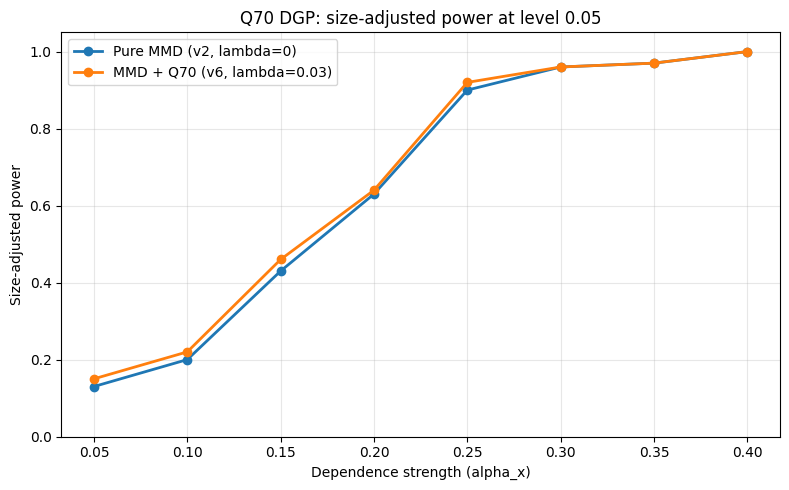

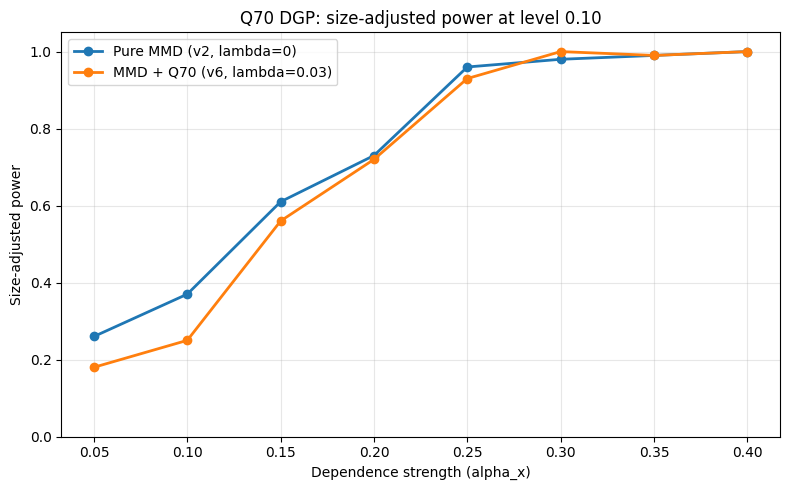

In [28]:
if not POWER_TABLE.empty:
    for level in (0.05,0.10):
        fig,ax=plt.subplots(figsize=(8,5))
        for method,group in POWER_TABLE.groupby('method_id',sort=False):
            group=group.sort_values('alpha_x')
            ax.plot(group.alpha_x,group[f'size_adjusted_power_{level:.2f}'],
                    marker='o',linewidth=2,label=METHOD_LABELS[method])
        ax.set(xlabel='Dependence strength (alpha_x)',ylabel='Size-adjusted power',
               title=f'Q70 DGP: size-adjusted power at level {level:.2f}',ylim=(0,1.05))
        ax.grid(True,alpha=.3); ax.legend(); fig.tight_layout()
        fig.savefig(OUTPUT_DIR/f'power_curve_{level:.2f}.png',dpi=200)
        plt.show()

## 10. Save complete available results

Configurations, raw p-values, calibration cutoffs, Type I error, raw power, and size-adjusted power are saved separately. This makes the chosen v2 baseline and v6 aligned settings directly reproducible.

In [29]:
if not CALIBRATION_TABLE.empty:
    CALIBRATION_TABLE.to_csv(OUTPUT_DIR/'h0_summary.csv',index=False)
if not POWER_TABLE.empty:
    POWER_TABLE.to_csv(OUTPUT_DIR/'power_long.csv',index=False)
arrays={}
for method,by_alpha in H1_RESULTS.items():
    for alpha,result in by_alpha.items():
        tag=f'{alpha:.2f}'.replace('.','p')
        key=f'{method}_alpha_{tag}'
        arrays[key]=np.asarray(result['pvalues'],dtype=float)
        arrays[key+'__metadata']=np.asarray(canonical(result['metadata']))
        arrays[key+'__seeds']=np.asarray(result['seeds'],dtype=np.int64)
if arrays: np.savez_compressed(OUTPUT_DIR/'h1_pvalues.npz',**arrays)
if ORACLE_RESULT is not None:
    np.savez_compressed(OUTPUT_DIR/'oracle_h0.npz',pvalues=ORACLE_RESULT['pvalues'],
                        seeds=np.asarray(ORACLE_RESULT['seeds']),
                        metadata=np.asarray(canonical(ORACLE_RESULT['metadata'])))
atomic_json(OUTPUT_DIR/'experiment_settings.json',dict(version='v7',comparison=COMPARISON_MODE,
    core_hash=CORE_HASH,n=N,data_kwargs=BASE_DATA_KWARGS,levels=list(LEVELS),
    methods=METHODS,parameter_sources={'pure_mmd':'supplied v2 baseline','q70_aligned':'v6 aligned default'},
    H0_seeds=H0_SEEDS,H1_seed_start=H1_SEED_START,H1_seed_stride=H1_SEED_STRIDE,
    H1_replications=N_REP_H1,alpha_grid=ALPHA_GRID,
    raw_rejection_rule='p < nominal level',adjusted_rejection_rule='p <= empirical cutoff'))
print('Saved results to:',OUTPUT_DIR.resolve())

NameError: name 'ORACLE_RESULT' is not defined